### EDA with python and applying Logistic Regression

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [64]:
train = pd.read_csv('data/titanic_train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


* sib sp - total count of spouse and siblings
* parch  - total count of children and parents


In [65]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [66]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

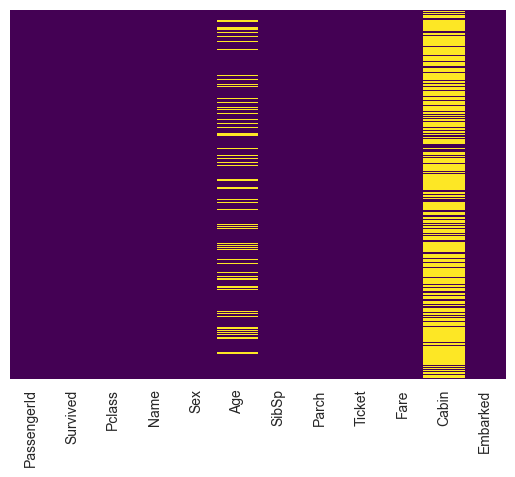

In [67]:
sns.heatmap(train.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

null values in yellow color

roughly 20% of age data is missing, the proportion is small so we can replace it, for cabin we have many data missing either we can drop the data or create another feature as cabin_known as 1 or 0.

<Axes: xlabel='Survived', ylabel='count'>

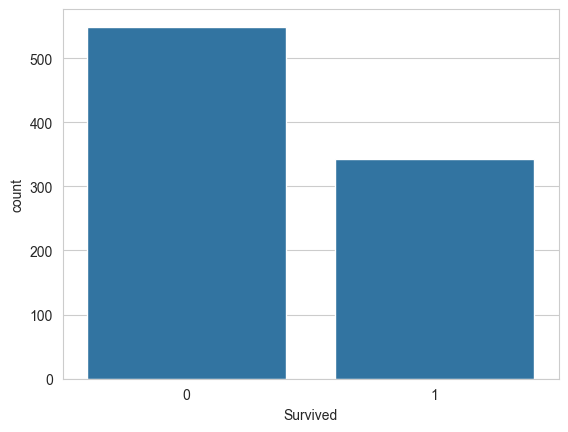

In [43]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived',data = train)

<Axes: xlabel='Survived', ylabel='count'>

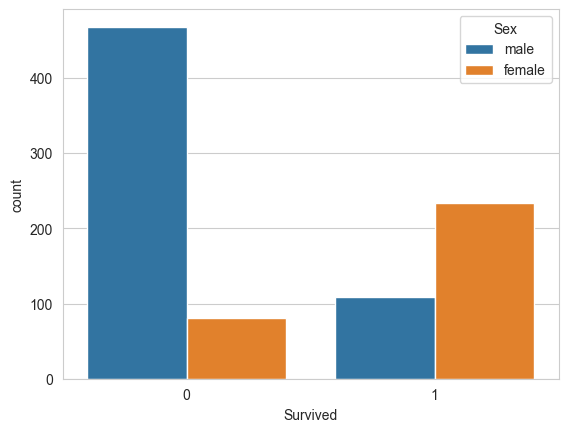

In [44]:
sns.countplot(x = 'Survived',hue = 'Sex',data = train)

many female survived compared to male

<Axes: xlabel='Survived', ylabel='count'>

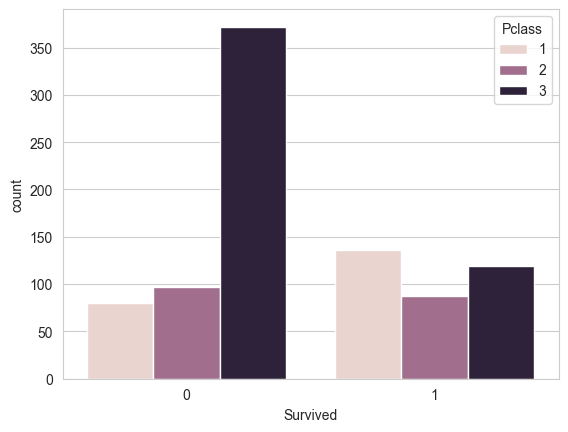

In [45]:
sns.countplot(x = 'Survived',hue = 'Pclass',data = train)

passengers from passeger class 1 survived and many people from class 3 died

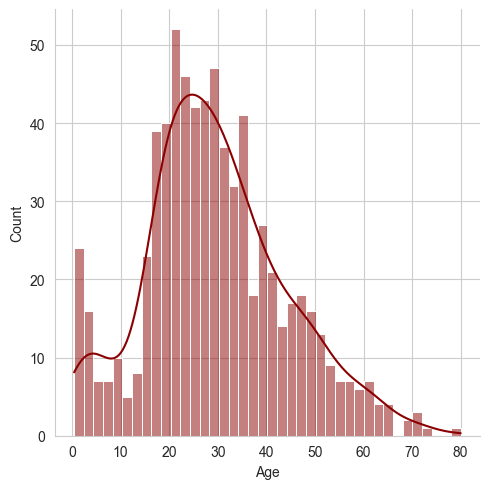

In [46]:
#average age of most of people that were in the ship

sns.displot(train['Age'].dropna(),kde = True,bins = 40,color = 'darkred')

<Axes: >

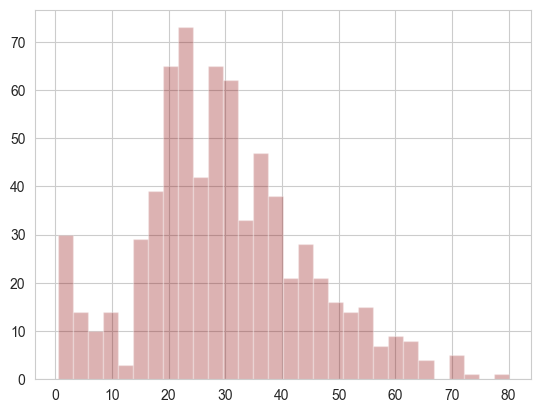

In [47]:
train['Age'].hist(bins= 30,color = 'darkred',alpha  =0.3)

C:\Users\megha\AppData\Local\Temp\ipykernel_22876\3962015563.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'SibSp',data = train,palette = 'rainbow')


<Axes: xlabel='SibSp', ylabel='count'>

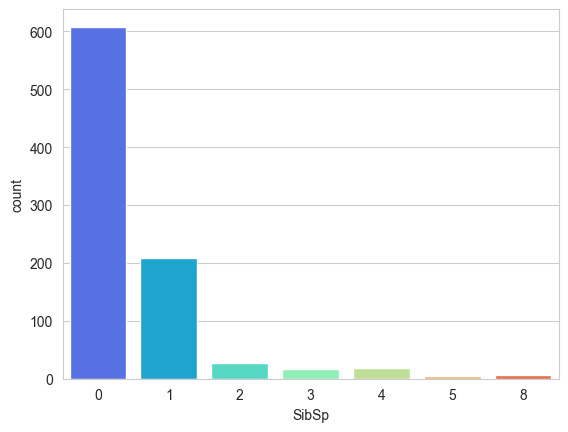

In [48]:
sns.countplot(x = 'SibSp',data = train,palette = 'rainbow')

many people did not have any siblings and spouse only 200 people has 1 sibling or spouse

<Axes: >

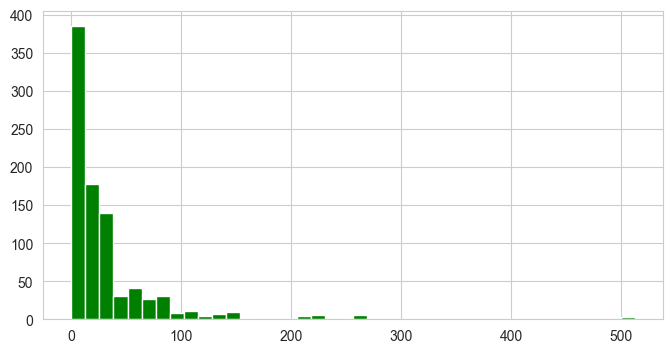

In [49]:
train['Fare'].hist(color = 'green',bins = 40,figsize = (8,4))

### Data cleaning

C:\Users\megha\AppData\Local\Temp\ipykernel_22876\3785880377.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Pclass',y = 'Age',data = train,palette = 'winter')


<Axes: xlabel='Pclass', ylabel='Age'>

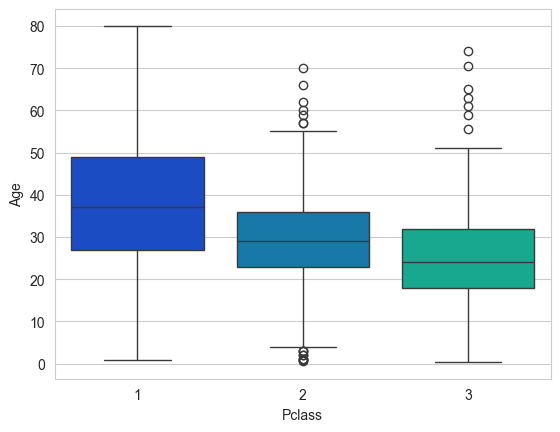

In [68]:
#is there any relationship btw Pclass and Age?
sns.boxplot(x = 'Pclass',y = 'Age',data = train,palette = 'winter')

In [74]:
#function to impute the average age based on the Pclass
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        if Pclass == 2:
            return 29
        if Pclass == 3:
            return 24
    else:
        return Age

In [75]:
train['Age'] = train[['Age','Pclass']].apply(impute_age,axis =1)

C:\Users\megha\AppData\Local\Temp\ipykernel_22876\3089410132.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\megha\AppData\Local\Temp\ipykernel_22876\3089410132.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


<Axes: >

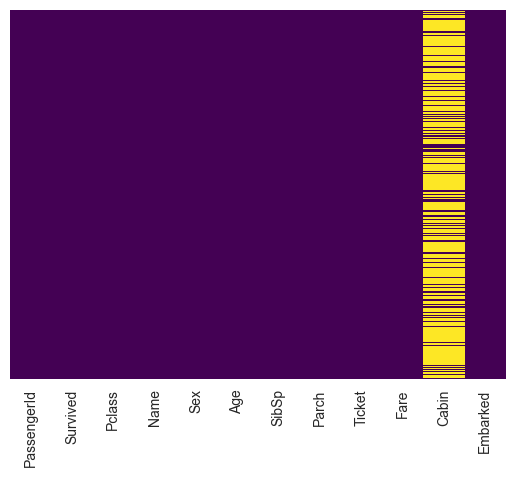

In [76]:
sns.heatmap(train.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

In [77]:
train.drop('Cabin',axis = 1,inplace = True)

<Axes: >

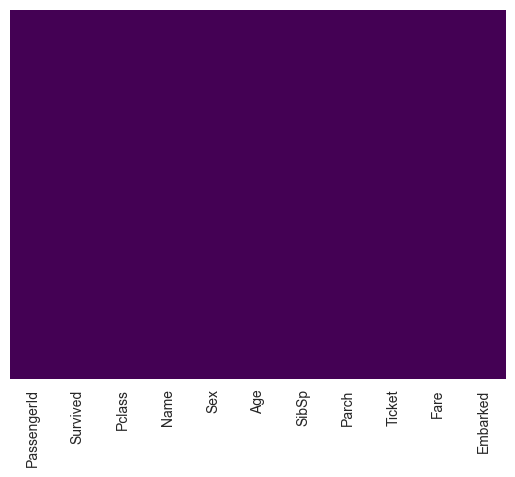

In [79]:
sns.heatmap(train.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

###  Converting Categorical features


<Axes: xlabel='Embarked', ylabel='count'>

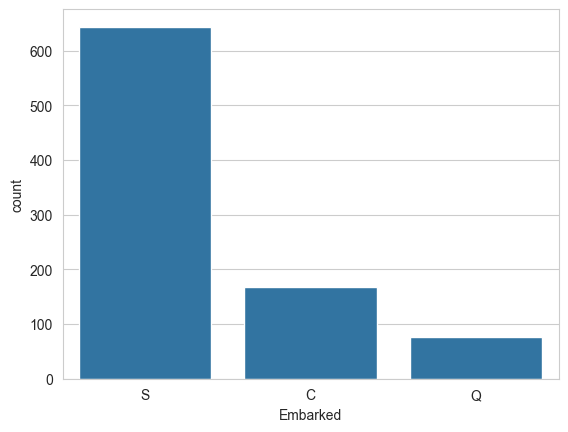

In [80]:
sns.countplot(x = 'Embarked',data = train)

In [82]:
pd.get_dummies(train['Embarked'],drop_first=True).head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [83]:
sex = pd.get_dummies(train['Sex'],drop_first = True)
embark = pd.get_dummies(train['Embarked'],drop_first = True)

In [84]:
train.drop(['Sex','Embarked','Name','Ticket'],axis = 1,inplace = True)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,24.0,1,0,7.2500
1,2,1,1,37.0,1,0,71.2833
2,3,1,3,24.0,0,0,7.9250
3,4,1,1,37.0,1,0,53.1000
4,5,0,3,24.0,0,0,8.0500


In [85]:
train = pd.concat([train,sex,embark],axis =1)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,24.0,1,0,7.2500,True,False,True
1,2,1,1,37.0,1,0,71.2833,False,False,False
2,3,1,3,24.0,0,0,7.9250,False,False,True
3,4,1,1,37.0,1,0,53.1000,False,False,True
4,5,0,3,24.0,0,0,8.0500,True,False,True


In [98]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   male         891 non-null    bool   
 8   Q            891 non-null    bool   
 9   S            891 non-null    bool   
dtypes: bool(3), float64(2), int64(5)
memory usage: 51.5 KB


In [86]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
male              bool
Q                 bool
S                 bool
dtype: object

### Buidling logistic regression model

#### Train test split

In [87]:
train.drop('Survived',axis = 1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,3,24.0,1,0,7.2500,True,False,True
1,2,1,37.0,1,0,71.2833,False,False,False
2,3,3,24.0,0,0,7.9250,False,False,True
3,4,1,37.0,1,0,53.1000,False,False,True
4,5,3,24.0,0,0,8.0500,True,False,True


In [88]:
train['Survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [90]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train,y_test = train_test_split(train.drop('Survived',axis = 1),
                                                  train['Survived'],test_size = 0.30,
                                                  random_state = 101
                                                  )


#### Training and predicting

In [91]:
from sklearn.linear_model import LogisticRegression

In [92]:
logmodel = LogisticRegression()
logmodel.fit(x_train,y_train)

c:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [94]:
predictions = logmodel.predict(x_test)

In [95]:
from sklearn.metrics import confusion_matrix

accuracy = confusion_matrix(y_test,predictions)

In [96]:
accuracy

array([[134,  20],
       [ 41,  73]])

In [97]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predictions)

0.7723880597014925